# EDA — `05_metadata` (RISA_DATA_V1.0)
**HealthSignal LATAM · Hackathon Perú 2026**

`05_metadata` no tiene observaciones de pacientes: son 4 catálogos de referencia
(`data_dictionary`, `source_catalog`, `units_catalog`, `variable_catalog`) que documentan *cómo
leer* el resto del paquete RISA. Por eso el EDA aquí no es "distribuciones de valores", sino una
**auditoría de consistencia**: ¿lo que dice el catálogo coincide con lo que de verdad aparece en
`01_master`–`04_context`? ¿Hay valores usados en los datos que el catálogo no documenta, o
entradas del catálogo que nunca se usan?

Esto es exactamente el tipo de verificación que sostiene la trazabilidad del prototipo: si una
alerta cita una unidad, una fuente o un rango de plausibilidad, ese dato tiene que ser
consistente de punta a punta con el catálogo — y este notebook deja esa consistencia comprobada
(o documenta dónde no se cumple).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

RAW_DIR  = "../data/raw"
META_DIR = f"{RAW_DIR}/05_metadata"

data_dictionary = pd.read_csv(f"{META_DIR}/data_dictionary.csv")
source_catalog  = pd.read_csv(f"{META_DIR}/source_catalog.csv")
units_catalog   = pd.read_csv(f"{META_DIR}/units_catalog.csv")
variable_catalog = pd.read_csv(f"{META_DIR}/variable_catalog.csv")

for name, df in [("data_dictionary", data_dictionary), ("source_catalog", source_catalog),
                  ("units_catalog", units_catalog), ("variable_catalog", variable_catalog)]:
    print(f"{name:18s} -> {df.shape[0]:3d} filas x {df.shape[1]} columnas")


data_dictionary    ->  11 filas x 5 columnas
source_catalog     ->   7 filas x 7 columnas
units_catalog      ->  13 filas x 6 columnas
variable_catalog   ->  15 filas x 8 columnas


## 1. `data_dictionary` — diccionario de datos

Solo 11 filas. Antes de asumir que es un diccionario exhaustivo, vale la pena comprobarlo contra
el número real de columnas del paquete.

In [2]:
data_dictionary

,file,field,type,key_role,description
0,01_master/patients.csv,patient_id,string,PK,Canonical synthetic patient identifier
1,01_master/encounters.csv,encounter_id,string,PK,Monitoring/attention episode
2,01_master/encounters.csv,patient_id,string,FK,Patient reference
3,02_clinical/laboratory_results.csv,sample_datetime,datetime,NaN,Sample collection time
4,02_clinical/laboratory_results.csv,result_datetime,datetime,NaN,Time result becomes available
5,03_monitoring/vital_signs.csv,timestamp,datetime,NaN,Measurement time
6,03_monitoring/vital_signs.csv,quality_flag,category,NaN,Observable quality metadata; not a risk label
7,03_monitoring/wearable_observations.csv,timestamp,datetime,NaN,Measurement/device time
8,03_monitoring/wearable_observations.csv,sync_datetime,datetime,NaN,Availability/synchronization time
9,04_context/patient_context.csv,start_datetime,datetime,NaN,Context interval start


In [3]:
total_cols = 0
schema = {}
for folder in ["01_master", "02_clinical", "03_monitoring", "04_context"]:
    for f in sorted(glob.glob(f"{RAW_DIR}/{folder}/*.csv")):
        cols = pd.read_csv(f, nrows=0).columns.tolist()
        rel = f.replace(f"{RAW_DIR}/", "")
        schema[rel] = cols
        total_cols += len(cols)

print(f"Total de columnas reales en 01_master..04_context: {total_cols}")
print(f"Filas documentadas en data_dictionary: {len(data_dictionary)}")
print(f"Cobertura del diccionario: {len(data_dictionary)/total_cols*100:.1f}%")

Total de columnas reales en 01_master..04_context: 119
Filas documentadas en data_dictionary: 11
Cobertura del diccionario: 9.2%


**Hallazgo:** `data_dictionary.csv` documenta solo el **9.2%** de las columnas del paquete
(11 de 119). No es un diccionario de datos exhaustivo — es más bien una **lista de campos
"delicados"**: casi todos son timestamps con matices (`sample_datetime` vs. `result_datetime`,
`timestamp` vs. `sync_datetime`) o campos que podrían confundirse con una etiqueta de riesgo
(`quality_flag`, `connectivity_status`). Es coherente con lo que ya encontramos en los EDAs
anteriores: son justamente los campos donde detectamos ambigüedad real (formatos mixtos,
`quality_flag` que no captura todo el ruido). El resto de las columnas del dataset (nombres,
identificadores, categorías directas) se documentan solo implícitamente por su nombre.

In [4]:
print("Verificación: ¿cada (file, field) del diccionario existe realmente en los CSV?\n")
ok = True
for _, row in data_dictionary.iterrows():
    f, field = row['file'], row['field']
    existe_archivo = f in schema
    existe_campo = existe_archivo and field in schema[f]
    ok &= existe_campo
    marca = "OK" if existe_campo else "!! FALTA"
    print(f"{marca:9s} {f:45s} {field}")
print("\n" + ("Las 11 entradas apuntan a columnas reales y existentes." if ok else "Hay entradas rotas."))

Verificación: ¿cada (file, field) del diccionario existe realmente en los CSV?

OK        01_master/patients.csv                        patient_id
OK        01_master/encounters.csv                      encounter_id
OK        01_master/encounters.csv                      patient_id
OK        02_clinical/laboratory_results.csv            sample_datetime
OK        02_clinical/laboratory_results.csv            result_datetime
OK        03_monitoring/vital_signs.csv                 timestamp
OK        03_monitoring/vital_signs.csv                 quality_flag
OK        03_monitoring/wearable_observations.csv       timestamp
OK        03_monitoring/wearable_observations.csv       sync_datetime
OK        04_context/patient_context.csv                start_datetime
OK        04_context/connectivity_events.csv            connectivity_status

Las 11 entradas apuntan a columnas reales y existentes.


## 2. `source_catalog` — sistemas de origen

7 sistemas de origen, cada uno con su latencia y nivel de interoperabilidad declarados.

In [5]:
source_catalog

,source_system,source_name,source_type,update_frequency,interoperability_level,typical_latency,description
0,EHR_CORE,RISA EHR Core,EHR,EVENT,HIGH,LOW,Encounter and context master data
1,EHR_MED,Medication Module,EHR,EVENT,HIGH,LOW,Medication events
2,LAB_SYS_A,Laboratory System A,LAB,EVENT,MEDIUM,30-180 min,Laboratory reporting
3,LAB_SYS_B,Laboratory System B,LAB,EVENT,MEDIUM,60-360 min,Alternate laboratory reporting
4,MONITOR_GATEWAY,Clinical Monitor Gateway,DEVICE_GATEWAY,5-60 min,HIGH,NEAR_REAL_TIME,Monitoring observations
5,MONITOR_RETRANSMIT,Monitor Retransmission,DEVICE_GATEWAY,VARIABLE,MEDIUM,DELAYED,Retransmitted observations
6,WEARABLE_GATEWAY,Wearable Gateway,WEARABLE_GATEWAY,5-15 min,MEDIUM,VARIABLE,Wearable/context streams


In [6]:
# Uso real de cada source_system/source en las tablas que lo registran
usage = {
    "01_master/encounters.csv":                       pd.read_csv(f"{RAW_DIR}/01_master/encounters.csv", usecols=['source_system'])['source_system'],
    "02_clinical/medication_administrations.csv":      pd.read_csv(f"{RAW_DIR}/02_clinical/medication_administrations.csv", usecols=['source_system'])['source_system'],
    "02_clinical/laboratory_results.csv":               pd.read_csv(f"{RAW_DIR}/02_clinical/laboratory_results.csv", usecols=['source_system'])['source_system'],
    "03_monitoring/vital_signs.csv":                    pd.read_csv(f"{RAW_DIR}/03_monitoring/vital_signs.csv", usecols=['source_system'])['source_system'],
    "03_monitoring/device_observations.csv":            pd.read_csv(f"{RAW_DIR}/03_monitoring/device_observations.csv", usecols=['source_system'])['source_system'],
    "04_context/patient_context.csv (col 'source')":    pd.read_csv(f"{RAW_DIR}/04_context/patient_context.csv", usecols=['source'])['source'],
}

used_all = set()
for f, s in usage.items():
    vals = s.unique().tolist()
    used_all.update(vals)
    print(f"{f:52s} -> {vals}")

catalog_sources = set(source_catalog['source_system'])
print("\nDeclarados en source_catalog pero NUNCA vistos en los datos:", catalog_sources - used_all)
print("Vistos en los datos pero NO declarados en source_catalog:   ", used_all - catalog_sources)

01_master/encounters.csv                             -> ['EHR_CORE']
02_clinical/medication_administrations.csv           -> ['EHR_MED']
02_clinical/laboratory_results.csv                   -> ['LAB_SYS_A', 'LAB_SYS_B']
03_monitoring/vital_signs.csv                        -> ['MONITOR_GATEWAY', 'MONITOR_RETRANSMIT']
03_monitoring/device_observations.csv                -> ['MONITOR_GATEWAY']
04_context/patient_context.csv (col 'source')        -> ['WEARABLE_GATEWAY']

Declarados en source_catalog pero NUNCA vistos en los datos: set()
Vistos en los datos pero NO declarados en source_catalog:    set()


**Hallazgo:** cobertura perfecta — los 7 `source_system` del catálogo aparecen en los datos y
no hay ninguno "huérfano" en ningún sentido. Vale la pena cruzar la latencia **declarada** contra
la latencia **observada**, ya con datos reales, para `LAB_SYS_A` vs. `LAB_SYS_B` (los dos sistemas
de laboratorio, vistos en el EDA de `02_clinical` como una sola tabla `laboratory_results` sin
distinguir fuente).

Registros de laboratorio por sistema de origen:
source_system
LAB_SYS_A    2319
LAB_SYS_B    2274
Name: count, dtype: int64

Tiempo de respuesta (turnaround) observado, por sistema:
                  mean       50%  min  max
source_system                             
LAB_SYS_A      1.76579  1.766667  0.5  3.0
LAB_SYS_B      3.21479  3.200000  0.5  6.0

Latencia DECLARADA en source_catalog:
  source_system typical_latency
2     LAB_SYS_A      30-180 min
3     LAB_SYS_B      60-360 min


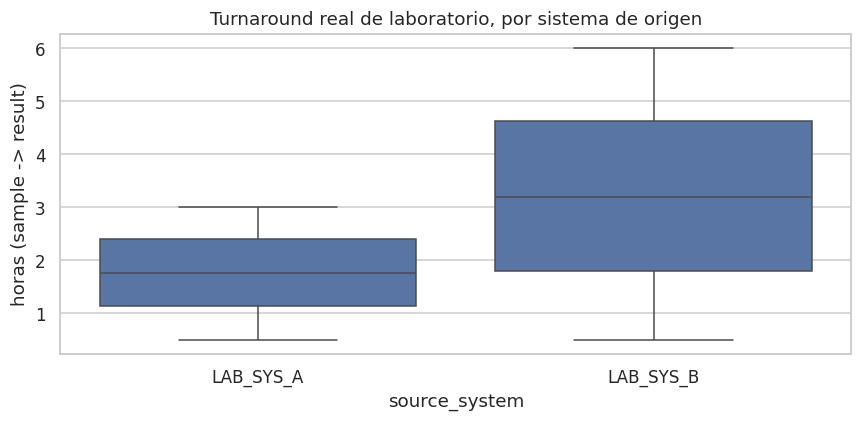

In [7]:
labs = pd.read_csv(f"{RAW_DIR}/02_clinical/laboratory_results.csv")
labs['sample_datetime'] = pd.to_datetime(labs['sample_datetime'], format='mixed')
labs['result_datetime'] = pd.to_datetime(labs['result_datetime'], format='mixed')
labs['tat_h'] = (labs['result_datetime'] - labs['sample_datetime']).dt.total_seconds() / 3600

print("Registros de laboratorio por sistema de origen:")
print(labs['source_system'].value_counts())

print("\nTiempo de respuesta (turnaround) observado, por sistema:")
print(labs.groupby('source_system')['tat_h'].describe()[['mean','50%','min','max']])

print("\nLatencia DECLARADA en source_catalog:")
print(source_catalog.loc[source_catalog['source_system'].isin(['LAB_SYS_A','LAB_SYS_B']),
                          ['source_system','typical_latency']])

plt.figure(figsize=(8, 4))
sns.boxplot(data=labs, x='source_system', y='tat_h', order=['LAB_SYS_A','LAB_SYS_B'], color='#4C72B0')
plt.ylabel('horas (sample -> result)')
plt.title('Turnaround real de laboratorio, por sistema de origen')
plt.tight_layout()
plt.show()

**Confirmación importante:** el turnaround real es consistente con lo declarado —
`LAB_SYS_A` (30–180 min declarados) promedia ~1.8 h observadas, y `LAB_SYS_B` (60–360 min
declarados) promedia ~3.2 h observadas, claramente más lento. Es una validación cruzada limpia:
el catálogo de fuentes **sí predice** el comportamiento real de los datos, y por lo tanto puede
usarse con confianza como prior de latencia/confiabilidad al fusionar fuentes en el pipeline
(algo que en el EDA de `02_clinical` habíamos visto como "el turnaround varía" sin poder explicar
por qué — ahora sabemos que es porque son dos sistemas de laboratorio distintos, no ruido).

## 3. `units_catalog` — unidades y factores de conversión

In [8]:
units_catalog

,unit_code,unit_name,dimension,canonical_unit,conversion_factor,conversion_offset
0,bpm,beats per minute,rate,bpm,1.000000,0.000000
1,rpm,respirations per minute,rate,rpm,1.000000,0.000000
2,%,percent,ratio,%,1.000000,0.000000
3,degC,degrees Celsius,temperature,degC,1.000000,0.000000
4,degF,degrees Fahrenheit,temperature,degC,0.555556,-17.777778
5,mmHg,millimeters mercury,pressure,mmHg,1.000000,0.000000
6,count,count,count,count,1.000000,0.000000
7,ratio,ratio,ratio,ratio,1.000000,0.000000
8,category,categorical,category,category,1.000000,0.000000
9,uA,synthetic lab unit A,lab,uA,1.000000,0.000000


In [9]:
# unidades usadas en las tablas de valores numéricos
units_used = {}
for f, col in [("02_clinical/laboratory_results.csv", "unit"),
               ("02_clinical/medication_administrations.csv", "dose_unit"),
               ("03_monitoring/vital_signs.csv", "unit"),
               ("03_monitoring/device_observations.csv", "unit"),
               ("03_monitoring/wearable_observations.csv", "unit")]:
    vals = pd.read_csv(f"{RAW_DIR}/{f}", usecols=[col])[col].unique().tolist()
    units_used[f] = vals
    print(f"{f:48s} -> {vals}")

all_units_used = set(v for vals in units_used.values() for v in vals)
catalog_units = set(units_catalog['unit_code'])
print("\nUsadas en los datos pero NO documentadas en units_catalog:", all_units_used - catalog_units)
print("Documentadas en units_catalog pero nunca usadas:            ", catalog_units - all_units_used)

02_clinical/laboratory_results.csv               -> ['uB', 'uC', 'uA', 'uD']
02_clinical/medication_administrations.csv       -> ['synthetic_unit']


03_monitoring/vital_signs.csv                    -> ['bpm', 'rpm', '%', 'degC', 'mmHg', 'degF']
03_monitoring/device_observations.csv            -> ['ratio']


03_monitoring/wearable_observations.csv          -> ['bpm', 'count', 'category']

Usadas en los datos pero NO documentadas en units_catalog: {'synthetic_unit'}
Documentadas en units_catalog pero nunca usadas:             set()


**Hallazgo real de inconsistencia:** `medication_administrations.dose_unit` usa el valor
`'synthetic_unit'`, que **no existe** en `units_catalog.csv`. No es un error grave (es coherente
con que las dosis de este dataset son sintéticas y no clínicamente interpretables), pero sí es
una brecha real de documentación: si el pipeline intenta normalizar unidades automáticamente
contra `units_catalog` para *todas* las columnas de unidad del dataset, `dose_unit` va a fallar
el lookup y debe manejarse como caso aparte (o excluirse de la normalización de unidades clínicas,
ya que la dosis no tiene una escala canónica real en esta versión sintética).

Unidades que SÍ requieren conversión real (factor != 1 u offset != 0):
  unit_code           unit_name    dimension canonical_unit  conversion_factor  conversion_offset
4      degF  degrees Fahrenheit  temperature           degC           0.555556         -17.777778


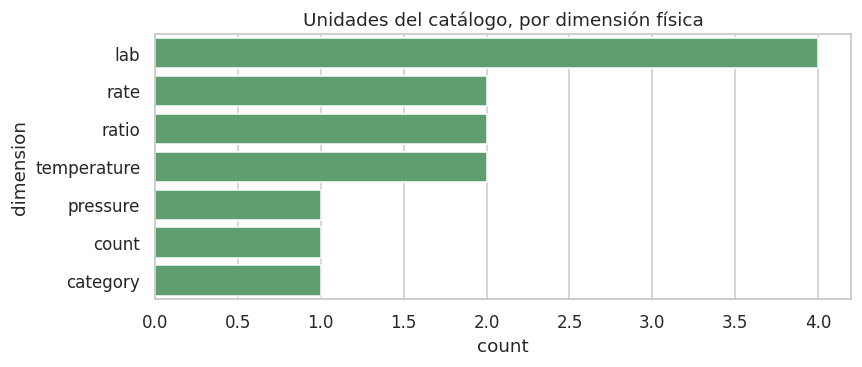

In [10]:
print("Unidades que SÍ requieren conversión real (factor != 1 u offset != 0):")
print(units_catalog[(units_catalog['conversion_factor'] != 1) | (units_catalog['conversion_offset'] != 0)])

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.countplot(data=units_catalog, y='dimension', order=units_catalog['dimension'].value_counts().index, color='#55A868', ax=ax)
ax.set_title('Unidades del catálogo, por dimensión física')
plt.tight_layout()
plt.show()

**Comentario:** de las 13 unidades catalogadas, **solo `degF` requiere una conversión real**
(factor 0.5556, offset -17.78 — la fórmula estándar F→C). Es la unidad detrás del hallazgo de
`TEMP` mixto que documentamos en el EDA de `03_monitoring`: el catálogo ya trae todo lo necesario
para corregirlo, el problema era no aplicarlo.

## 4. `variable_catalog` — variables clínicas/de monitoreo y sus rangos plausibles

15 variables, con dominio (`VITAL`/`WEARABLE`/`CONTEXT`/`DEVICE`/`LAB`), unidad canónica, rango
de plausibilidad y frecuencia de muestreo nominal.

In [11]:
variable_catalog

,variable_code,variable_name,domain,canonical_unit,plausibility_min,plausibility_max,nominal_sampling,analysis_role
0,HR,Heart Rate,VITAL,bpm,20.0,220.0,5-15 min,PERSONAL_BASELINE_RELEVANT
1,RR,Respiratory Rate,VITAL,rpm,5.0,60.0,10-30 min,PERSONAL_BASELINE_RELEVANT
2,SpO2,Oxygen Saturation,VITAL,%,50.0,100.0,5-15 min,PERSONAL_BASELINE_RELEVANT
3,TEMP,Temperature,VITAL,degC,30.0,45.0,30-240 min,PERSONAL_BASELINE_RELEVANT
4,SBP,Systolic Blood Pressure,VITAL,mmHg,60.0,240.0,30-360 min,PERSONAL_BASELINE_RELEVANT
5,DBP,Diastolic Blood Pressure,VITAL,mmHg,30.0,150.0,30-360 min,PERSONAL_BASELINE_RELEVANT
6,WEARABLE_HR,Wearable Heart Rate,WEARABLE,bpm,20.0,220.0,5-15 min,CONTEXT_SENSITIVE
7,STEPS,Step Count,WEARABLE,count,0.0,1000.0,5-15 min,CONTEXT
8,ACTIVITY_LEVEL,Activity Level,CONTEXT,category,NaN,NaN,INTERVAL,CONTEXT
9,SLEEP_STATE,Sleep State,CONTEXT,category,NaN,NaN,EPISODE,CONTEXT


In [12]:
print("Consistencia interna del catálogo:")
print("- canonical_unit que no está en units_catalog:",
      set(variable_catalog['canonical_unit']) - set(units_catalog['unit_code']))
rango = variable_catalog.dropna(subset=['plausibility_min','plausibility_max'])
inconsistentes = rango[rango['plausibility_min'] >= rango['plausibility_max']]
print("- filas con plausibility_min >= plausibility_max:", len(inconsistentes))

Consistencia interna del catálogo:
- canonical_unit que no está en units_catalog: set()
- filas con plausibility_min >= plausibility_max: 0


Ambas verificaciones salen limpias: toda unidad canónica referenciada existe en
`units_catalog`, y todos los rangos de plausibilidad están bien formados (`min < max`). Ahora el
cruce importante: **¿qué variable_code aparece realmente en los datos, y qué le falta o le sobra
al catálogo?**

In [13]:
varcodes_monitoring = set(pd.read_csv(f"{RAW_DIR}/03_monitoring/vital_signs.csv", usecols=['variable_code'])['variable_code'])
varcodes_device      = set(pd.read_csv(f"{RAW_DIR}/03_monitoring/device_observations.csv", usecols=['variable_code'])['variable_code'])
varcodes_wearable    = set(pd.read_csv(f"{RAW_DIR}/03_monitoring/wearable_observations.csv", usecols=['variable_code'])['variable_code'])
testcodes_labs       = set(pd.read_csv(f"{RAW_DIR}/02_clinical/laboratory_results.csv", usecols=['test_code'])['test_code'])

used_as_variable_code = varcodes_monitoring | varcodes_device | varcodes_wearable | testcodes_labs
catalog_vars = set(variable_catalog['variable_code'])

print("variable_code/test_code usados en vital_signs + device_observations + wearable_observations + labs:")
print(sorted(used_as_variable_code))
print("\nUsados pero NO en variable_catalog:", used_as_variable_code - catalog_vars)
print("En variable_catalog pero NUNCA usados como variable_code/test_code:", catalog_vars - used_as_variable_code)

variable_code/test_code usados en vital_signs + device_observations + wearable_observations + labs:
['ACTIVITY_LEVEL', 'DBP', 'HR', 'LAB_A', 'LAB_B', 'LAB_C', 'LAB_D', 'RR', 'SBP', 'SIGNAL_QUALITY_INDEX', 'STEPS', 'SpO2', 'TEMP', 'WEARABLE_HR']

Usados pero NO en variable_catalog: set()
En variable_catalog pero NUNCA usados como variable_code/test_code: {'SLEEP_STATE'}


**Hallazgo:** las 11 variables realmente medidas (HR, RR, SpO2, TEMP, SBP, DBP,
WEARABLE_HR, STEPS, ACTIVITY_LEVEL, SIGNAL_QUALITY_INDEX, LAB_A–D) están todas documentadas.
`SLEEP_STATE` es la única entrada de `variable_catalog` que **nunca aparece como
`variable_code`** en ninguna tabla de observaciones — porque en los datos reales `SLEEP_STATE`
no es una medición, sino un `context_type` en `patient_context.csv` (tabla completamente
distinta). Esto lleva al hallazgo más importante de esta sección: la relación entre
`variable_catalog` y el **vocabulario de contexto** de `04_context` no es 1 a 1.

In [14]:
context_types = set(pd.read_csv(f"{RAW_DIR}/04_context/patient_context.csv", usecols=['context_type'])['context_type'])
catalog_context_domain = set(variable_catalog.loc[variable_catalog['domain']=='CONTEXT', 'variable_code'])

print("context_type real en patient_context.csv:      ", context_types)
print("variable_catalog con domain == 'CONTEXT':        ", catalog_context_domain)
print()
print("Coinciden:        ", context_types & catalog_context_domain)
print("Solo en los datos (sin definición en el catálogo):", context_types - catalog_context_domain)
print("Solo en el catálogo (sin uso como context_type):   ", catalog_context_domain - context_types)

context_type real en patient_context.csv:       {'SLEEP_STATE', 'RECOVERY_PHASE', 'PHYSICAL_ACTIVITY'}
variable_catalog con domain == 'CONTEXT':         {'SLEEP_STATE', 'ACTIVITY_LEVEL'}

Coinciden:         {'SLEEP_STATE'}
Solo en los datos (sin definición en el catálogo): {'RECOVERY_PHASE', 'PHYSICAL_ACTIVITY'}
Solo en el catálogo (sin uso como context_type):    {'ACTIVITY_LEVEL'}


**Hallazgo de inconsistencia real (el más relevante de este notebook):**
`patient_context.csv` usa los `context_type` **`PHYSICAL_ACTIVITY`** y **`RECOVERY_PHASE`**, que
**no existen en `variable_catalog`** — el catálogo solo define `ACTIVITY_LEVEL` (que en los datos
reales es el `variable_code` de `wearable_observations`, no el `context_type` de
`patient_context`) y `SLEEP_STATE` (que sí coincide). Es decir: hay dos vocabularios de "nivel de
actividad" ligeramente distintos en el dataset (`ACTIVITY_LEVEL` como variable de wearable,
`PHYSICAL_ACTIVITY` como tipo de contexto) y el catálogo solo cubre el primero.

**Implicación para HealthSignal:** si el motor de explicabilidad arma sus descripciones citando
`variable_catalog` como única fuente de verdad, va a poder explicar `SLEEP_STATE` pero **no**
`PHYSICAL_ACTIVITY` ni `RECOVERY_PHASE` — dos de las tres categorías de contexto usadas en el
70%+ de los registros de `patient_context` (ver EDA de `04_context`). Antes de construir el motor
de trazabilidad, conviene ampliar el diccionario de variables para cubrir explícitamente el
vocabulario de `context_type`, o mantener un mapeo documentado entre ambos vocabularios.

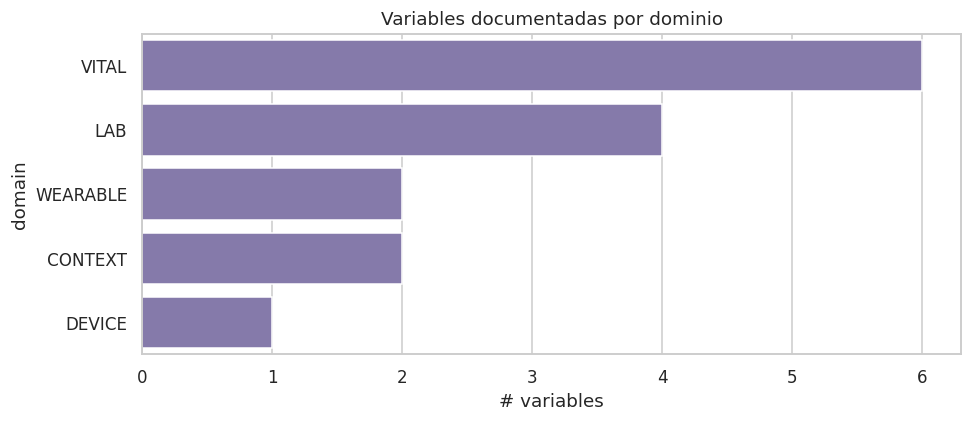

domain    analysis_role             
CONTEXT   CONTEXT                       2
DEVICE    QUALITY                       1
LAB       MULTISOURCE                   4
VITAL     PERSONAL_BASELINE_RELEVANT    6
WEARABLE  CONTEXT_SENSITIVE             1
          CONTEXT                       1
Name: count, dtype: int64


In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
domains = variable_catalog['domain'].value_counts()
sns.barplot(x=domains.values, y=domains.index, color='#8172B2', ax=ax)
ax.set_title('Variables documentadas por dominio')
ax.set_xlabel('# variables')
plt.tight_layout()
plt.show()

print(variable_catalog.groupby('domain')['analysis_role'].value_counts())

**Comentario:** `analysis_role` es en sí mismo un metadato valioso para diseñar el motor de
señales: `PERSONAL_BASELINE_RELEVANT` (los 6 signos vitales) sugiere que el umbral relevante es
el propio histórico del paciente, no un corte poblacional único; `MULTISOURCE` (los 4 marcadores
de laboratorio) avisa que esas variables pueden llegar por más de un sistema de origen (confirmado
en la sección 2 con `LAB_SYS_A`/`LAB_SYS_B`); `QUALITY` (`SIGNAL_QUALITY_INDEX`) marca
explícitamente que esa variable es un metadato de confianza y no debe tratarse como señal clínica
directa.

## 5. Resumen ejecutivo del EDA de `05_metadata`

**Lo que está bien documentado:**

- `source_catalog`: cobertura perfecta (7/7 sistemas de origen usados y documentados en ambas
  direcciones), y la latencia declarada por sistema **predice correctamente** el comportamiento
  real observado en `laboratory_results` (`LAB_SYS_A` más rápido que `LAB_SYS_B`, tal como se
  declara).
- `units_catalog`: consistente puertas adentro (toda `canonical_unit` de `variable_catalog`
  existe aquí) y cubre todas las unidades clínicas usadas, salvo una excepción puntual.
- `variable_catalog`: rangos de plausibilidad bien formados, y las 11 variables realmente
  medidas en `vital_signs`/`device_observations`/`wearable_observations`/`laboratory_results`
  están completamente documentadas.

**Brechas de documentación encontradas (accionables antes de construir el pipeline):**

1. `data_dictionary.csv` documenta solo el 9.2% de las columnas del paquete (11/119) — es una
   lista de campos delicados, no un diccionario exhaustivo. El resto del esquema debe inferirse
   por convención de nombres.
2. `dose_unit = 'synthetic_unit'` (en `medication_administrations`) no está en `units_catalog` —
   cualquier normalización automática de unidades debe excluir esta columna o tratarla aparte.
3. **El vocabulario de `context_type` de `patient_context.csv` (`PHYSICAL_ACTIVITY`,
   `RECOVERY_PHASE`) no está cubierto por `variable_catalog`** — solo `SLEEP_STATE` coincide.
   Esta es la brecha más importante: afecta directamente la capacidad de explicar de forma
   consistente las categorías de contexto que alimentan al motor de señales.

**Siguiente paso sugerido:** antes de escribir el pipeline de integración, extender
`variable_catalog` (o crear un mapeo documentado aparte) para cubrir `PHYSICAL_ACTIVITY` y
`RECOVERY_PHASE`, y decidir explícitamente cómo tratar `dose_unit`. Con eso, las 5 capas del
dataset (`01_master` a `05_metadata`) quedan completamente auditadas y las reglas de
normalización/plausibilidad/deduplicación identificadas en los 4 EDAs anteriores pueden
codificarse con la confianza de que los catálogos de referencia son consistentes con los datos
reales — con las tres excepciones puntuales documentadas arriba.
